# Importaciones

In [2]:
import gensim

In [3]:
import spacy

spacy.prefer_gpu()
nlp = spacy.load("es_core_news_md")

In [4]:
import pandas as pd

df = pd.read_csv("./corpus_readability_v1.csv")

In [5]:
df

,Unnamed: 0,texto,doc_id,tiempo_segundos,dificultad
0,0,"El cambio climático es un problema sistémico, ...",0,91.053333,3
1,1,Alumnos de los Talleres Libres de Danza hicier...,1,41.530000,2
2,2,Para conocer las bondades que ofrece la Univer...,2,84.000000,1
3,3,ARTÍCULO 98. Se otorgará mención honorífica cu...,3,37.000000,2
4,4,Artículo 7. La persona titular de la Defensorí...,4,67.253333,2
...,...,...,...,...,...
95,95,Ya circula la Gaceta Unison con información de...,95,45.126667,2
96,96,Este miércoles 8 de marzo da comienzo la tempo...,96,87.000000,2
97,97,ARTÍCULO 46. Los planes de estudio de cada pro...,97,48.000000,1
98,98,Con la participación de 26 alumnas de la Licen...,98,217.300000,4


___

# Limpieza

## Lematización

In [6]:
def clean_and_lemmatize(texts, disable_ner_parser=True):
    clean_texts = []
    for doc in nlp.pipe(texts, batch_size=2000, disable=["ner", "parser"] if disable_ner_parser else []):
        tokens = [
            token.lemma_.lower() 
            for token in doc 
            if not token.is_stop and token.is_alpha
        ]
        clean_texts.append(" ".join(tokens))
    return clean_texts

In [7]:
df['texto'] = clean_and_lemmatize(df['texto'].astype(str))

## Etiquetas

In [8]:
df["dificultad"] = df["dificultad"] - 1

___

# Tokenización con Doc2Vec

In [9]:
from gensim.models.doc2vec import Doc2Vec, TaggedDocument

In [10]:
texts = df["texto"].astype(str)

tagged_docs = [
    TaggedDocument(words=row['texto'].split(), tags=[str(row['doc_id'])]) 
    for index, row in df.iterrows()
]

In [11]:
model = Doc2Vec(
    vector_size=100,
    epochs=5
)

model.build_vocab(tagged_docs)

model.train(
    tagged_docs,
    total_examples=model.corpus_count,
    epochs=model.epochs
)

In [12]:
doc_vectors = [model.dv[str(i)] for i in range(len(df))]

___

# Clasificación

In [13]:
from sklearn.preprocessing import LabelEncoder

y = LabelEncoder().fit_transform(df['dificultad'].values)

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(doc_vectors, y,
                                                            test_size=0.20,
                                                            stratify=y,
                                                            random_state=10)

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report, confusion_matrix

In [20]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

pred_train = lr.predict(X_train)
pred_test = lr.predict(X_test)

results = {
    "pred_train": pred_train,
    "pred_test": pred_test,
    "f1_test": f1_score(y_test, pred_test, average='weighted'),
    "confusion_matrix_test": confusion_matrix(y_test, pred_test),
    "classification_report_test": classification_report(y_test, pred_test)
}

/home/Fer/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/Fer/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/Fer/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [17]:
def print_results(model, predictions):
    print(f"Resultados para {model}:")
    print(f"F1 Score: {predictions['f1_test']:.4f}")
    print("Confusion Matrix:")
    print(predictions['confusion_matrix_test'])
    print("\n")

In [18]:
print_results("Logistic Regression", results)

Resultados para Logistic Regression:
F1 Score: 0.2286
Confusion Matrix:
[[0 4 0 0]
 [0 8 0 0]
 [0 5 0 0]
 [0 3 0 0]]




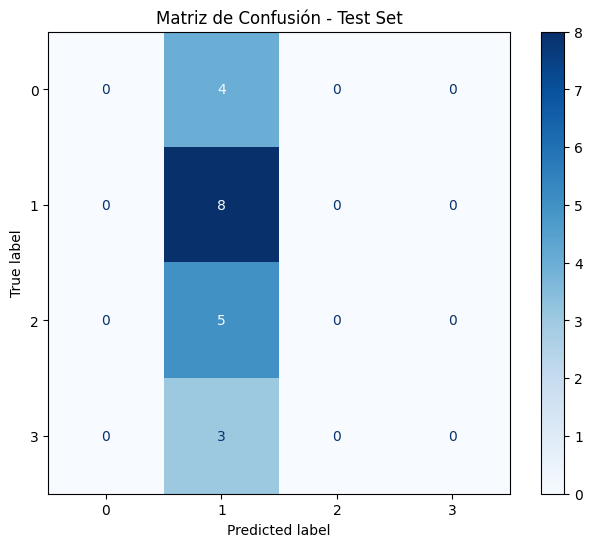

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = results["confusion_matrix_test"]

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap='Blues', ax=ax)

plt.title('Matriz de Confusión - Test Set')
plt.show()